In [1]:
# -*- coding: utf-8 -*-
"""
Indices de prix immobiliers hédoniques – Normandie
Méthodologie : UE Conduite de Projet, M1 SE – Université de Strasbourg
"""

# ── 0. Dépendances ────────────────────────────────────────────────────────────
!pip install -q numpy pandas scikit-learn matplotlib seaborn requests pyarrow openpyxl

import warnings, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")
for d in ["data/raw", "data/processed", "outputs"]:
    Path(d).mkdir(parents=True, exist_ok=True)


In [2]:
# ── 1. Configuration ──────────────────────────────────────────────────────────
DEPARTEMENTS      = {"14":"Calvados","27":"Eure","50":"Manche","61":"Orne","76":"Seine-Maritime"}
ANNEES            = list(range(2019, 2025))
BASE_URL          = "https://files.data.gouv.fr/geo-dvf/latest/csv/{annee}/departements/{dep}.csv.gz"
REFERENCE_PERIODE = "2020-07"   # t₀ – base 100
MIN_OBS_COMMUNE   = 30          # seuil d'identification de μ_c (slide 11)
PRICE_SQM_MIN, PRICE_SQM_MAX = 300, 20_000
SURFACE_MIN, SURFACE_MAX     = 9, 1_000
COLS_KEEP = ["date_mutation","valeur_fonciere","code_commune","nom_commune",
             "code_departement","type_local","surface_reelle_bati",
             "nombre_pieces_principales","nature_mutation"]
DEPT_COLORS = {"14":"#2196F3","27":"#4CAF50","50":"#FF9800","61":"#9C27B0","76":"#F44336"}

print("Configuration OK")

Configuration OK


In [3]:
# ── 2. Téléchargement DVF+ ────────────────────────────────────────────────────
def download_all(force=False):
    for dep in DEPARTEMENTS:
        for annee in ANNEES:
            dest = Path(f"data/raw/dvf_{dep}_{annee}.csv.gz")
            if dest.exists() and not force:
                continue
            r = requests.get(BASE_URL.format(annee=annee, dep=dep), timeout=120)
            if r.status_code == 200:
                dest.write_bytes(r.content); print(f"  ✓ {dest.name}")
            else:
                print(f"  ✗ HTTP {r.status_code} – {dep}/{annee}")

download_all()

  ✗ HTTP 404 – 14/2019
  ✗ HTTP 404 – 27/2019
  ✗ HTTP 404 – 50/2019
  ✗ HTTP 404 – 61/2019
  ✗ HTTP 404 – 76/2019


In [4]:
# ── 3. Chargement et nettoyage ────────────────────────────────────────────────
# Étape 1 du cours : yᵢ = log(price_sqmᵢ)
def load_and_clean():
    dfs = []
    for dep in DEPARTEMENTS:
        for annee in ANNEES:
            p = Path(f"data/raw/dvf_{dep}_{annee}.csv.gz")
            if p.exists():
                df = pd.read_csv(p, compression="gzip", low_memory=False)
                dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    print(f"Brut : {len(df):,} lignes")

    cols = [c for c in COLS_KEEP if c in df.columns]
    df = df[cols].copy()
    if "nature_mutation" in df.columns:
        df = df[df["nature_mutation"] == "Vente"]
    df = df[df["type_local"].isin(["Maison","Appartement"])]

    df["valeur_fonciere"]     = pd.to_numeric(df["valeur_fonciere"],     errors="coerce")
    df["surface_reelle_bati"] = pd.to_numeric(df["surface_reelle_bati"], errors="coerce")
    df["date_mutation"]       = pd.to_datetime(df["date_mutation"],      errors="coerce")
    df = df.dropna(subset=["valeur_fonciere","surface_reelle_bati","date_mutation","code_commune"])

    # pᵢ = prix au m², yᵢ = log(pᵢ)  [slide 9]
    df["price_sqm"]     = df["valeur_fonciere"] / df["surface_reelle_bati"]
    df = df[df["surface_reelle_bati"].between(SURFACE_MIN, SURFACE_MAX) &
            df["price_sqm"].between(PRICE_SQM_MIN, PRICE_SQM_MAX)]
    df["log_price_sqm"] = np.log(df["price_sqm"])   # yᵢ

    # Variables temporelles : t(i) = mois×année, a(i) = année  [slide 9]
    df["annee"]      = df["date_mutation"].dt.year
    df["periode"]    = (df["annee"].astype(str) + "-"
                        + df["date_mutation"].dt.month.astype(str).str.zfill(2))
    df["annee_mois"] = pd.to_datetime(df["periode"])

    # Localisation : c(i), d(i)  [slide 9]
    df["code_commune"] = df["code_commune"].astype(str).str.zfill(5)
    df["code_dep"]     = df["code_commune"].str[:2]

    # Caractéristiques du bien xᵢ : typologies T  [slide 9]
    if "nombre_pieces_principales" in df.columns:
        nb = pd.to_numeric(df["nombre_pieces_principales"], errors="coerce").fillna(0).astype(int).clip(0, 8)
        df["typo_T"] = nb.apply(lambda x: f"T{x}" if 1 <= x <= 4 else ("T5+" if x >= 5 else "T?"))
    else:
        df["typo_T"] = "T?"

    print(f"Propre : {len(df):,} lignes | {df['type_local'].value_counts().to_dict()}")
    return df.reset_index(drop=True)

df = load_and_clean()
df.to_parquet("data/processed/dvf_clean.parquet", index=False)

Brut : 1,007,635 lignes
Propre : 328,489 lignes | {'Maison': 240468, 'Appartement': 88021}


In [5]:
# ── 4. Modèle hédonique OLS ───────────────────────────────────────────────────
# Étapes 2–4 du cours :
#   yᵢ = α + xᵢ'β + γ_{t(i)} + δ_{d(i)} + μ_{c(i)} + θ_{d(i),a(i)} + εᵢ
#   θ̂ = argmin ‖y − Xθ‖²
#   log Pᵢⁿᵉᵗ = ŷᵢ − Σ_{k∈H} β̂_k xᵢₖ      (H = variables qualité)

def estimate_hedonic(df_type, type_bien):
    print(f"\n{'='*55}\n  Modèle hédonique – {type_bien}  ({len(df_type):,} obs)\n{'='*55}")
    df = df_type.copy()

    # Grandes communes (effectif ≥ seuil) → dummy μ_c identifiable  [slide 11]
    grande = df["code_commune"].value_counts()
    grande = grande[grande >= MIN_OBS_COMMUNE].index
    df["commune_fe"] = df["code_commune"].where(df["code_commune"].isin(grande), "_petite_")
    df["dep_annee"]  = df["code_dep"] + "_" + df["annee"].astype(str)   # θ_{d,a}

    # Étape 2 – dummies (drop_first ↔ catégorie de référence)  [slide 10]
    X = pd.concat([
        pd.get_dummies(df["periode"],    prefix="t",     drop_first=True, dtype=float),  # γ_t
        pd.get_dummies(df["code_dep"],   prefix="dep",   drop_first=True, dtype=float),  # δ_d
        pd.get_dummies(df["commune_fe"], prefix="com",   drop_first=True, dtype=float),  # μ_c
        pd.get_dummies(df["dep_annee"],  prefix="dep_a", drop_first=True, dtype=float),  # θ_{d,a}
        pd.get_dummies(df["typo_T"],     prefix="typo",  drop_first=True, dtype=float),  # xᵢ
    ], axis=1)

    y   = df["log_price_sqm"].values
    Xv  = X.values.astype(np.float32)
    print(f"  Dim X : {Xv.shape}")

    # Étape 3 – estimation OLS  [slide 12]
    reg   = LinearRegression(fit_intercept=True, n_jobs=-1).fit(Xv, y)
    y_hat = reg.predict(Xv)
    print(f"  R² = {r2_score(y, y_hat):.4f}")

    # Étape 4 – log Pᵢⁿᵉᵗ = ŷᵢ − contribution qualité  [slide 13]
    qual_idx = [list(X.columns).index(c) for c in X.columns if c.startswith("typo_")]
    df["log_price_net"] = y_hat - Xv[:, qual_idx] @ reg.coef_[qual_idx]

    # Correction des petites communes : log Pᵢⁿᵉᵗ ← log Pᵢⁿᵉᵗ + ē_{c(i)}  [slide 15]
    df["residual"] = y - y_hat
    petites = df["commune_fe"] == "_petite_"
    if petites.any():
        e_bar = df.loc[petites].groupby("code_commune")["residual"].mean()
        df.loc[petites, "log_price_net"] += (
            df.loc[petites, "code_commune"].map(e_bar).fillna(0).values
        )

    return df

results = {tb: estimate_hedonic(df[df["type_local"] == tb].copy(), tb)
           for tb in ["Maison","Appartement"]
           if (df["type_local"] == tb).sum() >= 100}


  Modèle hédonique – Maison  (240,468 obs)
  Dim X : (240468, 1954)
  R² = 0.2845

  Modèle hédonique – Appartement  (88,021 obs)
  Dim X : (88021, 294)
  R² = 0.2299


In [6]:
# ── 5. Construction de l'indice base 100 ─────────────────────────────────────
# Étapes 5–6 du cours :
#   log P^net_{c,t} = médiane{log Pᵢⁿᵉᵗ : c(i)=c, t(i)=t}  [slide 14]
#   → panel cylindré + interpolation (zéro NaN)              [slide 16]
#   Index_{c,t} = 100 × exp(log P^net_{c,t} − log P^net_{c,t₀})  [slide 17]

def build_index(df_type):
    # Agrégation médiane par (commune, période)
    agg = (df_type.groupby(["code_commune","nom_commune","code_dep","periode"])
           ["log_price_net"]
           .agg(log_net_med="median", n_obs="count")
           .reset_index())

    # Panel cylindré {c} × {t}
    periodes = sorted(agg["periode"].unique())
    communes = agg[["code_commune","nom_commune","code_dep"]].drop_duplicates()
    panel = (communes.assign(_k=1)
             .merge(pd.DataFrame({"periode": periodes, "_k": 1}), on="_k")
             .drop("_k", axis=1)
             .merge(agg, on=["code_commune","nom_commune","code_dep","periode"], how="left"))

    panel = panel.sort_values(["code_commune","periode"]).reset_index(drop=True)
    panel["annee_mois"] = pd.to_datetime(panel["periode"])
    panel["n_obs"]      = panel["n_obs"].fillna(0).astype(int)
    panel["is_pred"]    = panel["log_net_med"].isna()

    # Compléter les dates manquantes : interpolation linéaire → ffill → bfill
    # Garantit zéro valeur manquante dans la série  [slide 16]
    panel["log_net"] = (panel.groupby("code_commune")["log_net_med"]
                             .transform(lambda s: s.interpolate("linear").ffill().bfill()))

    # Référence t₀ (fallback = première valeur disponible si t₀ absent)
    ref = (panel[panel["periode"] == REFERENCE_PERIODE][["code_commune","log_net"]]
           .rename(columns={"log_net": "log_ref"}))
    fb  = (panel.groupby("code_commune")["log_net"].first().rename("log_ref_fb"))
    panel = panel.merge(ref, on="code_commune", how="left").merge(fb, on="code_commune", how="left")
    panel["log_ref"] = panel["log_ref"].fillna(panel["log_ref_fb"])
    panel.drop("log_ref_fb", axis=1, inplace=True)

    # Index_{c,t} = 100 × exp(log P^net_{c,t} − log P^net_{c,t₀})
    panel["index_prix"] = 100 * np.exp(panel["log_net"] - panel["log_ref"])

    # Benchmark départemental
    ref_d = (panel[panel["periode"] == REFERENCE_PERIODE]
             .groupby("code_dep")["log_net"].median().rename("log_ref_d"))
    bench = (panel.groupby(["code_dep","periode","annee_mois"])["log_net"]
             .median().rename("log_dept").reset_index()
             .merge(ref_d, on="code_dep", how="left"))
    bench["index_dept"] = 100 * np.exp(bench["log_dept"] - bench["log_ref_d"])

    nan_idx = panel["index_prix"].isna().sum()
    print(f"  NaN dans Index_{{c,t}} : {nan_idx}  {'✓' if nan_idx == 0 else '⚠'}")
    return panel, bench

indices = {}
for tb, df_type in results.items():
    panel, bench = build_index(df_type)
    indices[tb] = {"panel": panel, "bench": bench}

  NaN dans Index_{c,t} : 0  ✓
  NaN dans Index_{c,t} : 0  ✓


In [7]:
# ── 6. Visualisations ─────────────────────────────────────────────────────────

# 6a – Courbes temporelles  [objectif (2) slide 4]
def plot_temporal(panel, bench, type_bien, top_n=5):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(rf"$\mathrm{{Index}}_{{c,t}}$ – {type_bien}s  (base 100 = {REFERENCE_PERIODE})",
                 fontsize=13, fontweight="bold")

    # Top communes par volume de transactions
    top = panel.groupby("code_commune")["n_obs"].sum().nlargest(top_n).index
    ax  = axes[0]
    for i, code in enumerate(top):
        s = panel[panel["code_commune"] == code].sort_values("annee_mois")
        ax.plot(s["annee_mois"], s["index_prix"],
                label=f"{s['nom_commune'].iloc[0]} ({s['code_dep'].iloc[0]})",
                color=plt.cm.tab10.colors[i], lw=1.8)
    ax.axhline(100, color="grey", ls="--", lw=0.8)
    ax.set_title(f"Top {top_n} communes (volume)")
    ax.set_ylabel(r"$\mathrm{Index}_{c,t}$")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

    # Benchmarks départementaux
    ax = axes[1]
    for dep, label in DEPARTEMENTS.items():
        s = bench[bench["code_dep"] == dep].sort_values("annee_mois")
        if not s.empty:
            ax.plot(s["annee_mois"], s["index_dept"],
                    label=f"{dep} – {label}", color=DEPT_COLORS[dep], lw=2)
    ax.axhline(100, color="grey", ls="--", lw=0.8)
    ax.set_title("Benchmarks départementaux")
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"outputs/courbes_{type_bien.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()

# 6b – Heatmap commune × temps  [objectif (2) slide 4]
def plot_heatmap(panel, type_bien, dep="76", top_n=25):
    sub = panel[panel["code_dep"] == dep]
    if sub.empty:
        return
    top_c = sub.groupby("code_commune")["n_obs"].sum().nlargest(top_n).index
    pivot = (sub[sub["code_commune"].isin(top_c)]
             .pivot_table(index="nom_commune", columns="periode",
                          values="index_prix", aggfunc="first")
             .sort_index())

    fig, ax = plt.subplots(figsize=(18, max(8, len(pivot) * 0.38)))
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=100, vmin=70, vmax=150,
                linewidths=0.3, linecolor="white",
                cbar_kws={"label": fr"$\mathrm{{Index}}_{{c,t}}$ (base 100 = {REFERENCE_PERIODE})"})
    ax.set_title(
        fr"Heatmap $\mathrm{{Index}}_{{c,t}}$ – {type_bien}s | "
        f"Dép. {dep} – {DEPARTEMENTS.get(dep,'')}\n"
        "Lignes = communes  |  Colonnes = périodes",
        fontsize=12)
    step = max(1, len(pivot.columns) // 12)
    ax.set_xticks(range(0, len(pivot.columns), step))
    ax.set_xticklabels([pivot.columns[i] for i in range(0, len(pivot.columns), step)],
                       rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"outputs/heatmap_{type_bien.lower()}_dep{dep}.png", dpi=150, bbox_inches="tight")
    plt.show()

# 6c – Tableau récapitulatif
def make_summary_table(panel, bench, type_bien):
    t_min   = bench["periode"].min()
    t_max   = bench["periode"].max()
    n_years = (pd.to_datetime(t_max) - pd.to_datetime(t_min)).days / 365.25

    rows = []
    for dep, label in DEPARTEMENTS.items():
        b = bench[bench["code_dep"] == dep].set_index("periode")["index_dept"]
        if b.empty:
            continue
        idx_0  = b.get(t_min, np.nan)
        idx_T  = b.get(t_max, np.nan)
        croiss = (idx_T / idx_0 - 1) * 100 if not np.isnan(idx_0) else np.nan
        cagr   = ((idx_T / 100) ** (1 / n_years) - 1) * 100 if not np.isnan(idx_T) else np.nan
        rows.append({
            "Dép."            : dep,
            "Nom"             : label,
            f"Index {t_max}"  : round(idx_T,  1),
            "Croissance (%)": round(croiss, 1),
            "CAGR (% / an)" : round(cagr,   2),
            "Communes"        : panel[panel["code_dep"] == dep]["code_commune"].nunique(),
            "Transactions"    : int(panel[panel["code_dep"] == dep]["n_obs"].sum()),
        })

    tbl = pd.DataFrame(rows)
    tbl.to_csv(f"outputs/tableau_recap_{type_bien.lower()}.csv", index=False)
    print(f"\n{'='*70}\n  Tableau récapitulatif – {type_bien}s\n{'='*70}")
    print(tbl.to_string(index=False))
    return tbl


############################################################
  Visualisations – Maisons
############################################################


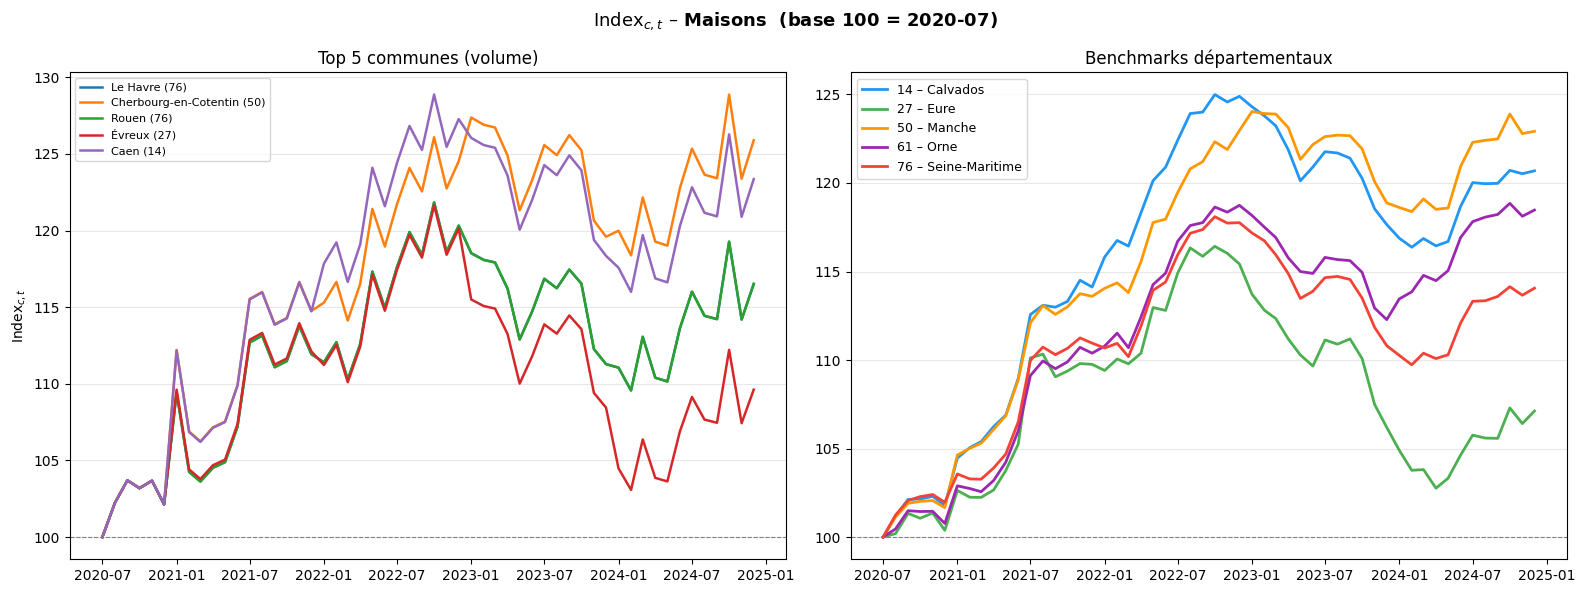

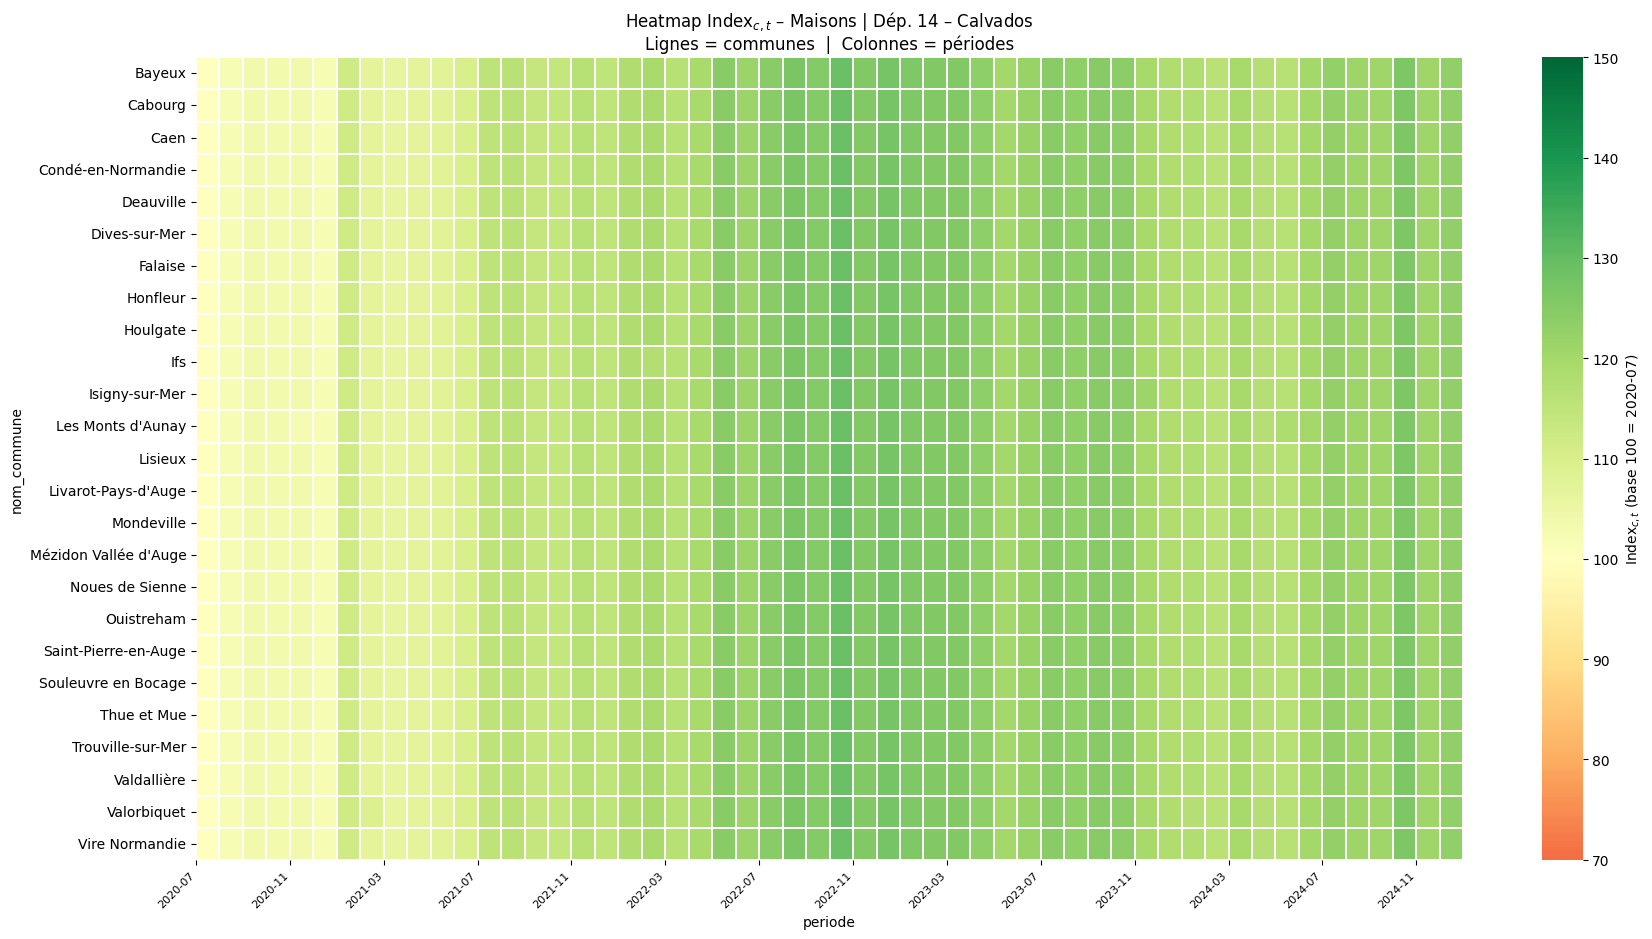

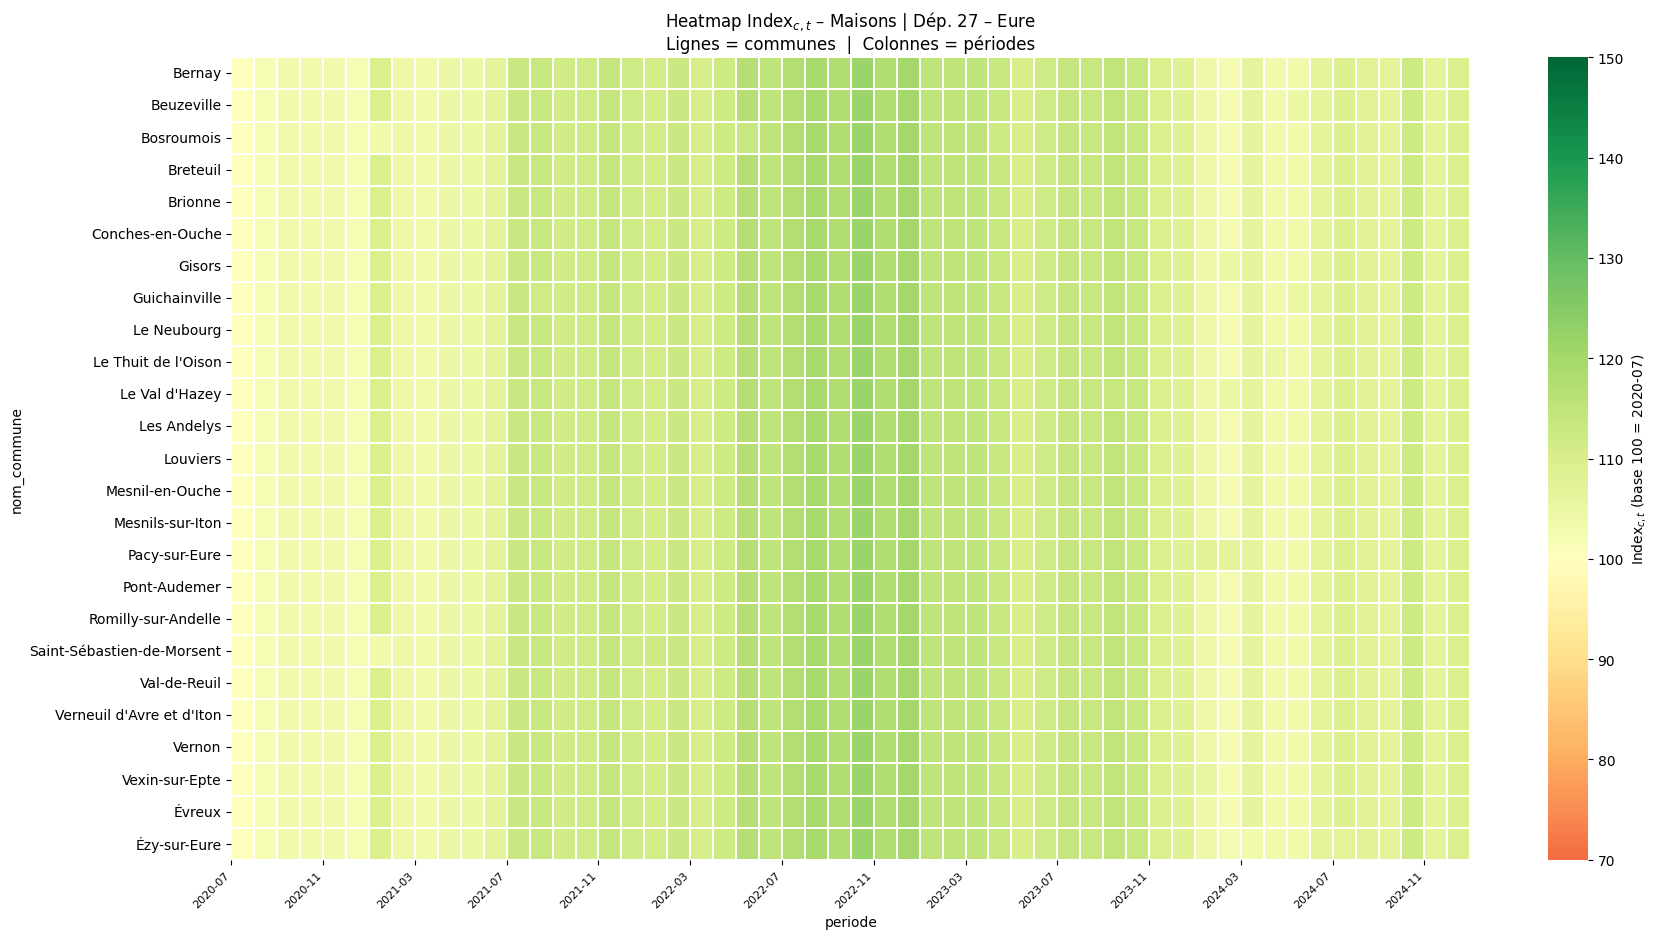

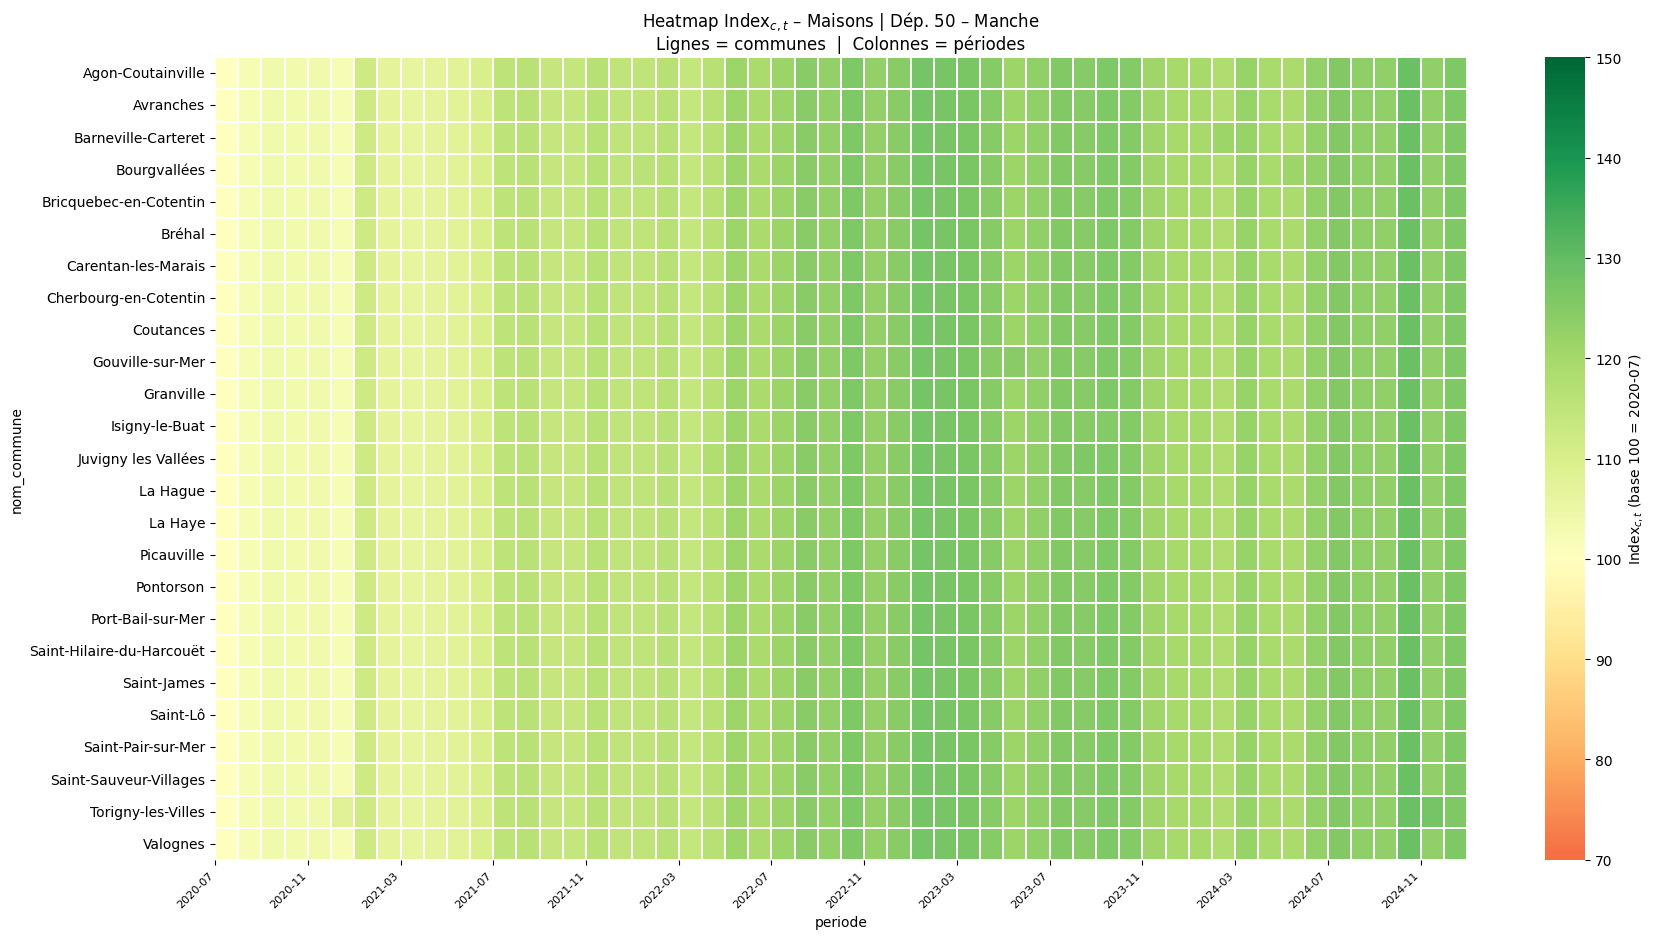

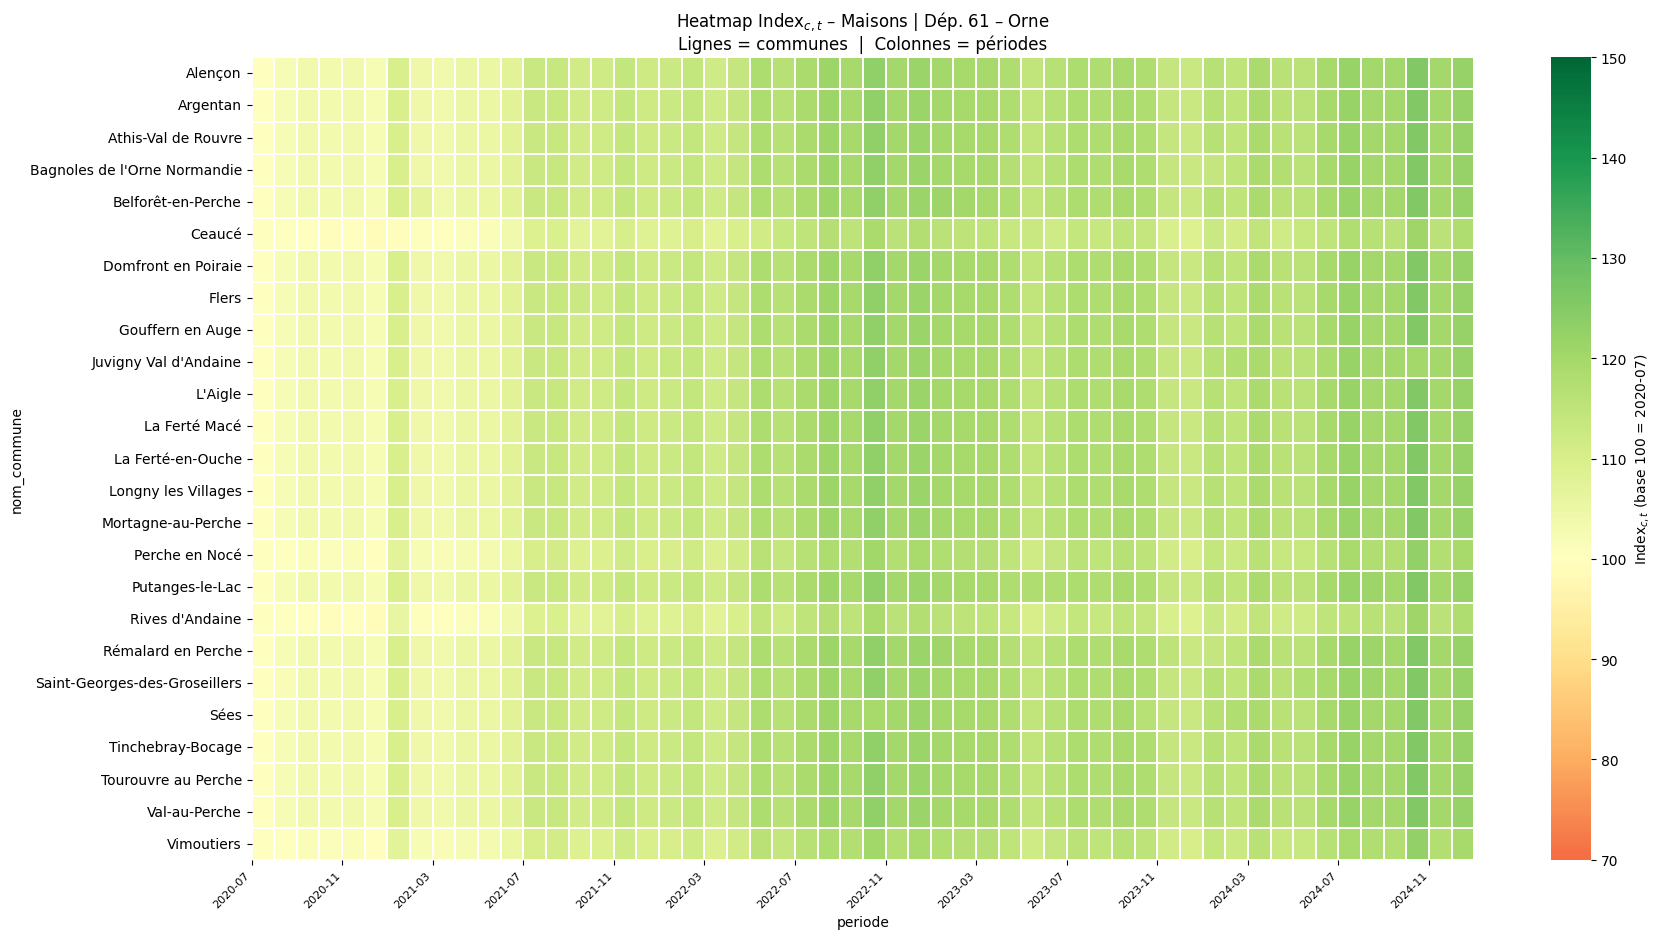

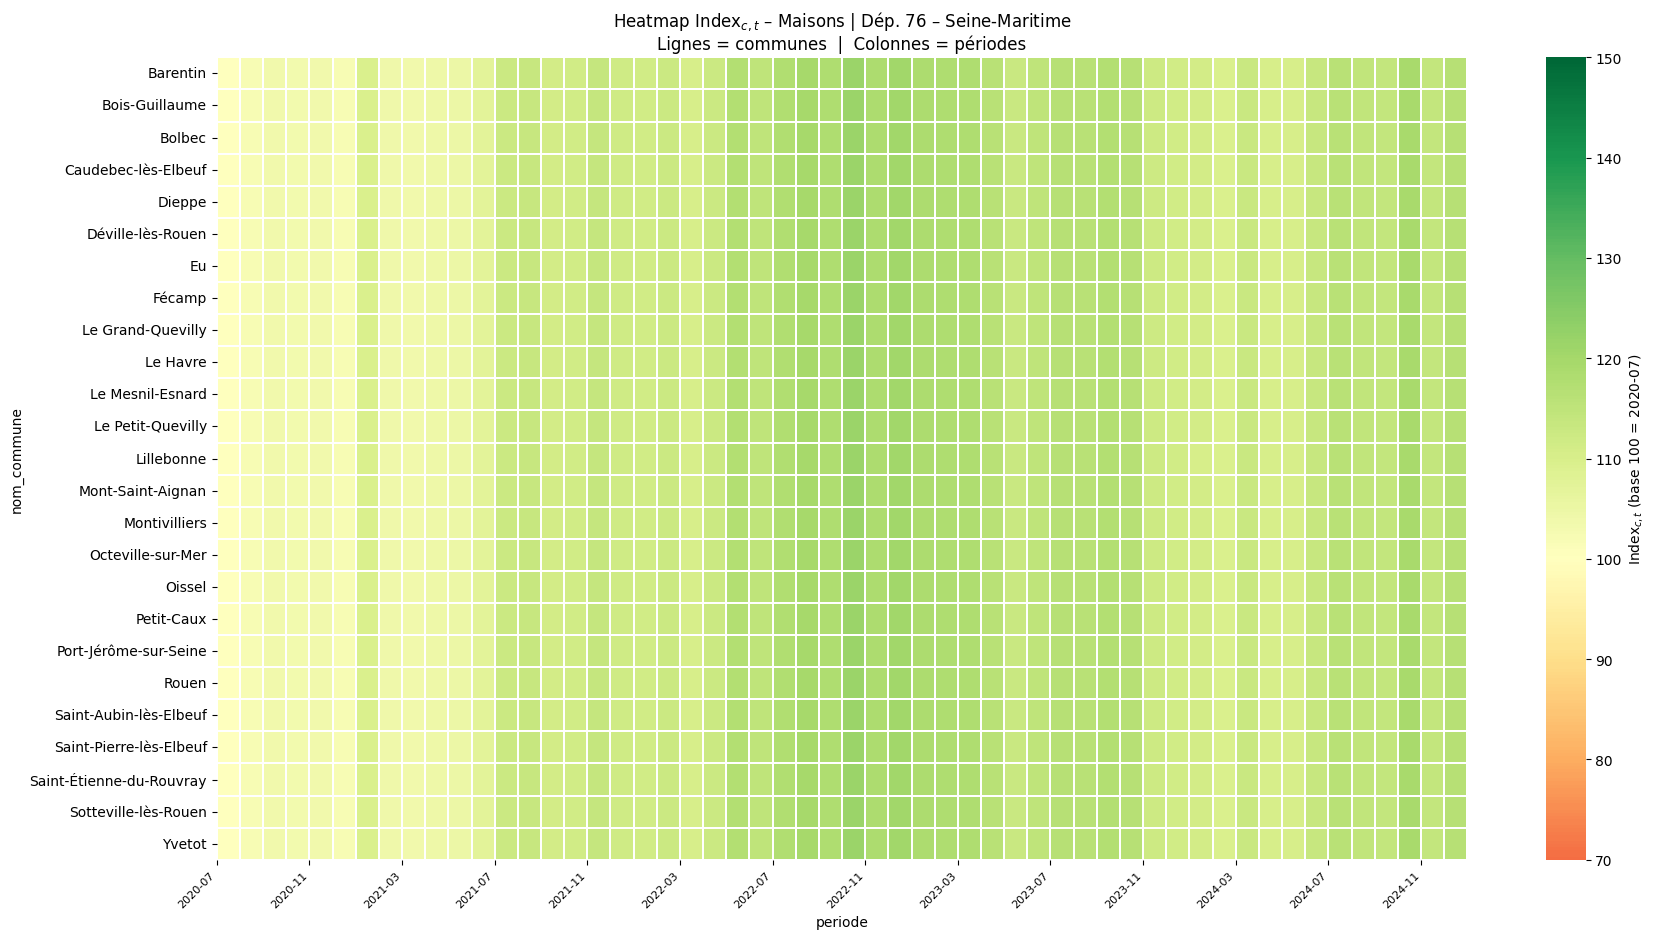


  Tableau récapitulatif – Maisons
Dép.            Nom  Index 2024-12  Croissance (%)  CAGR (% / an)  Communes  Transactions
  14       Calvados          120.7            20.7           4.35       528         50523
  27           Eure          107.1             7.1           1.57       585         49754
  50         Manche          122.9            22.9           4.78       445         45638
  61           Orne          118.5            18.5           3.91       385         26090
  76 Seine-Maritime          114.1            14.1           3.02       707         68463

############################################################
  Visualisations – Appartements
############################################################


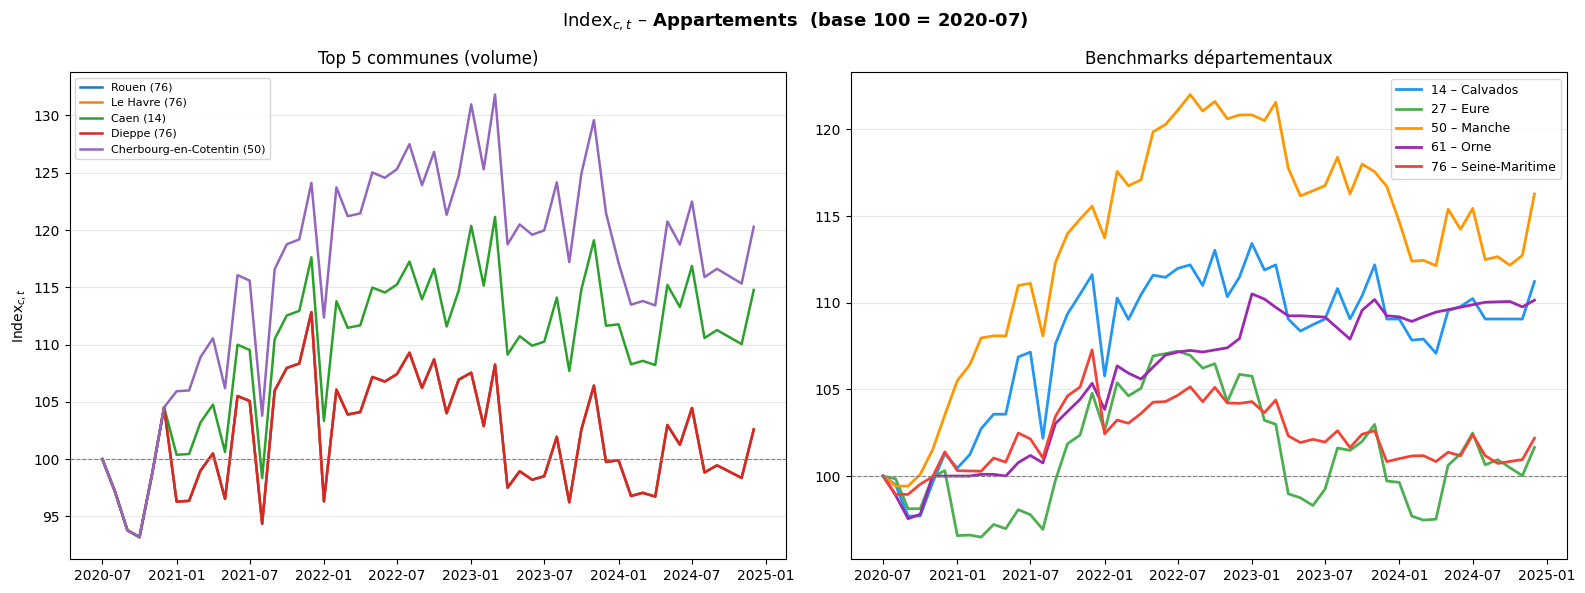

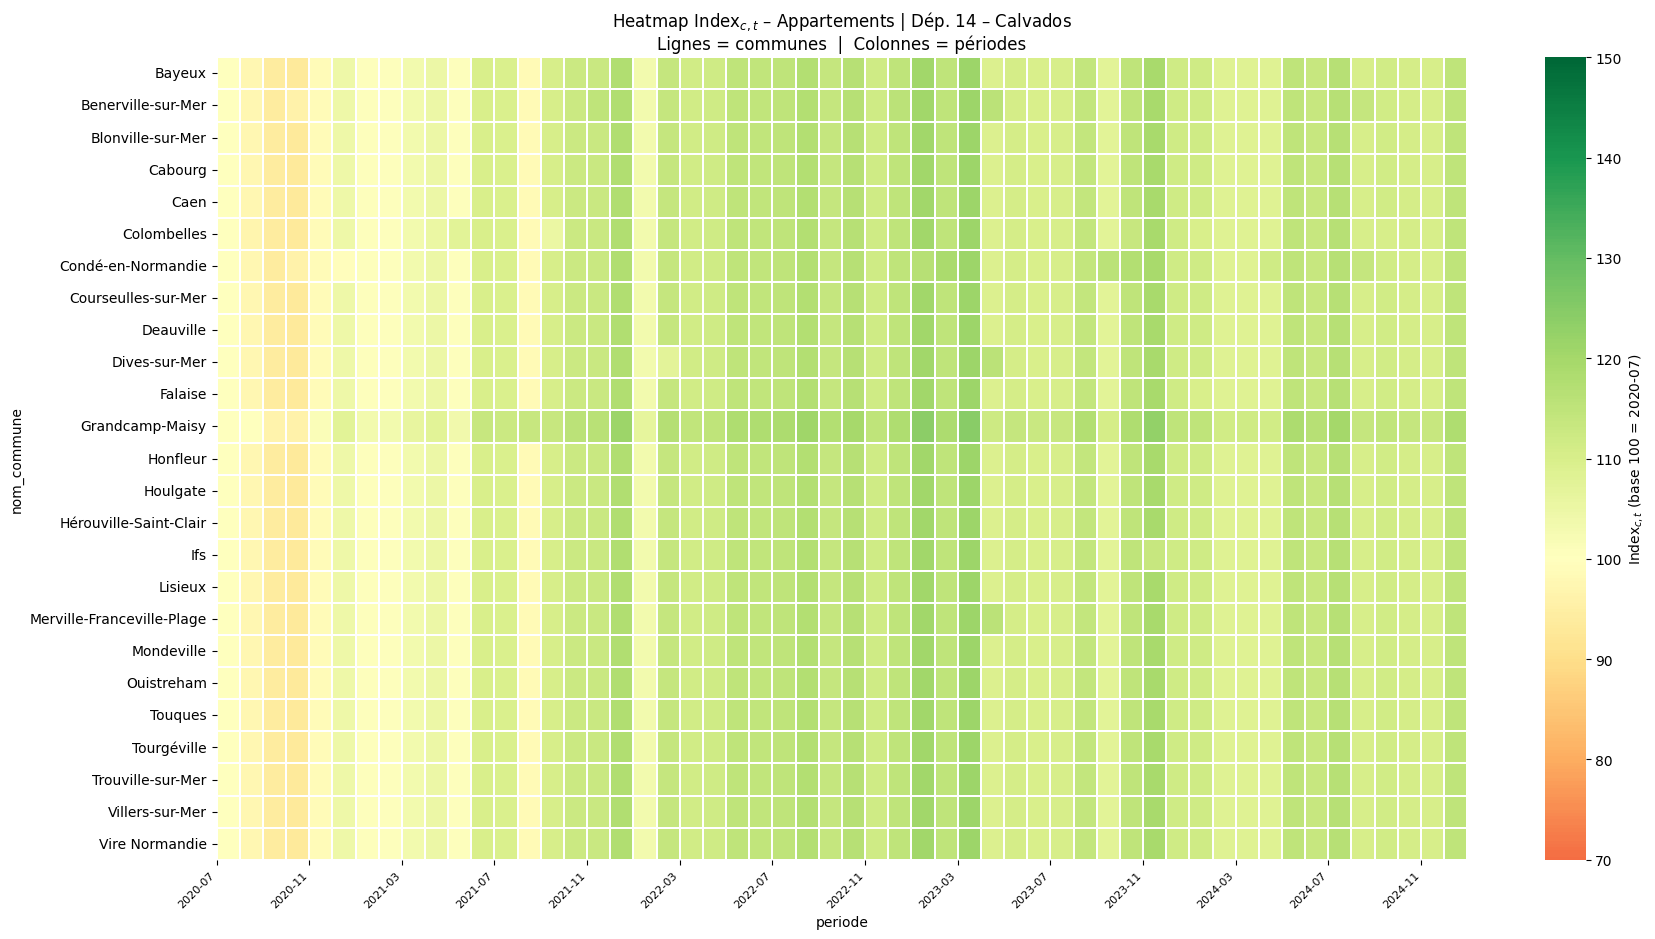

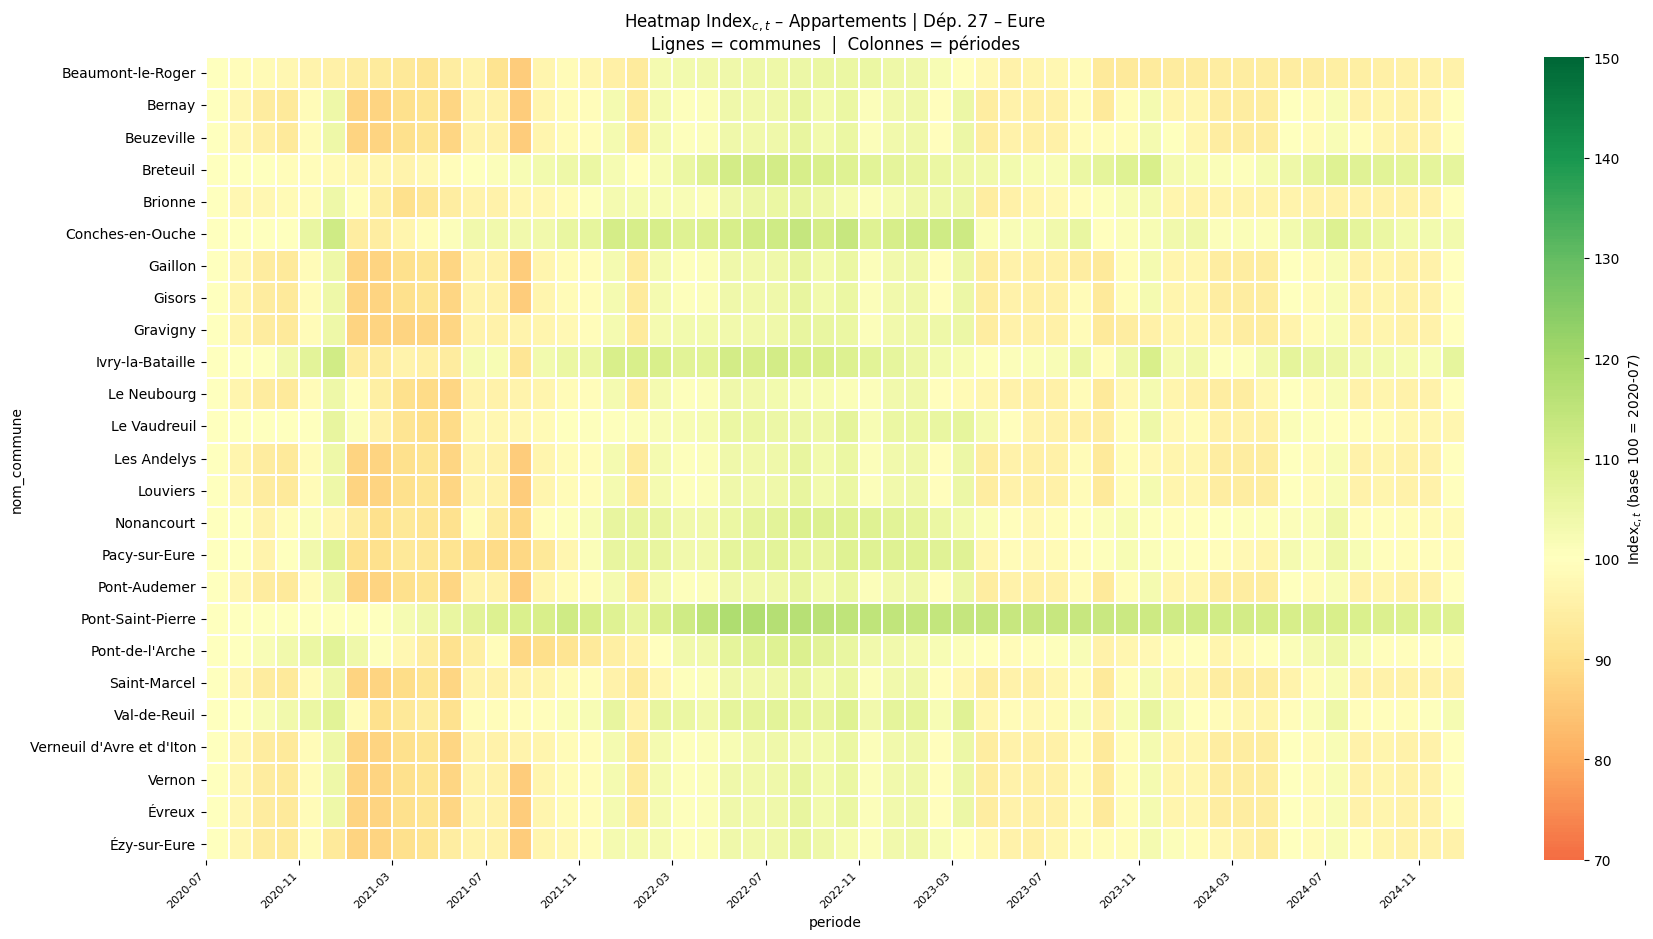

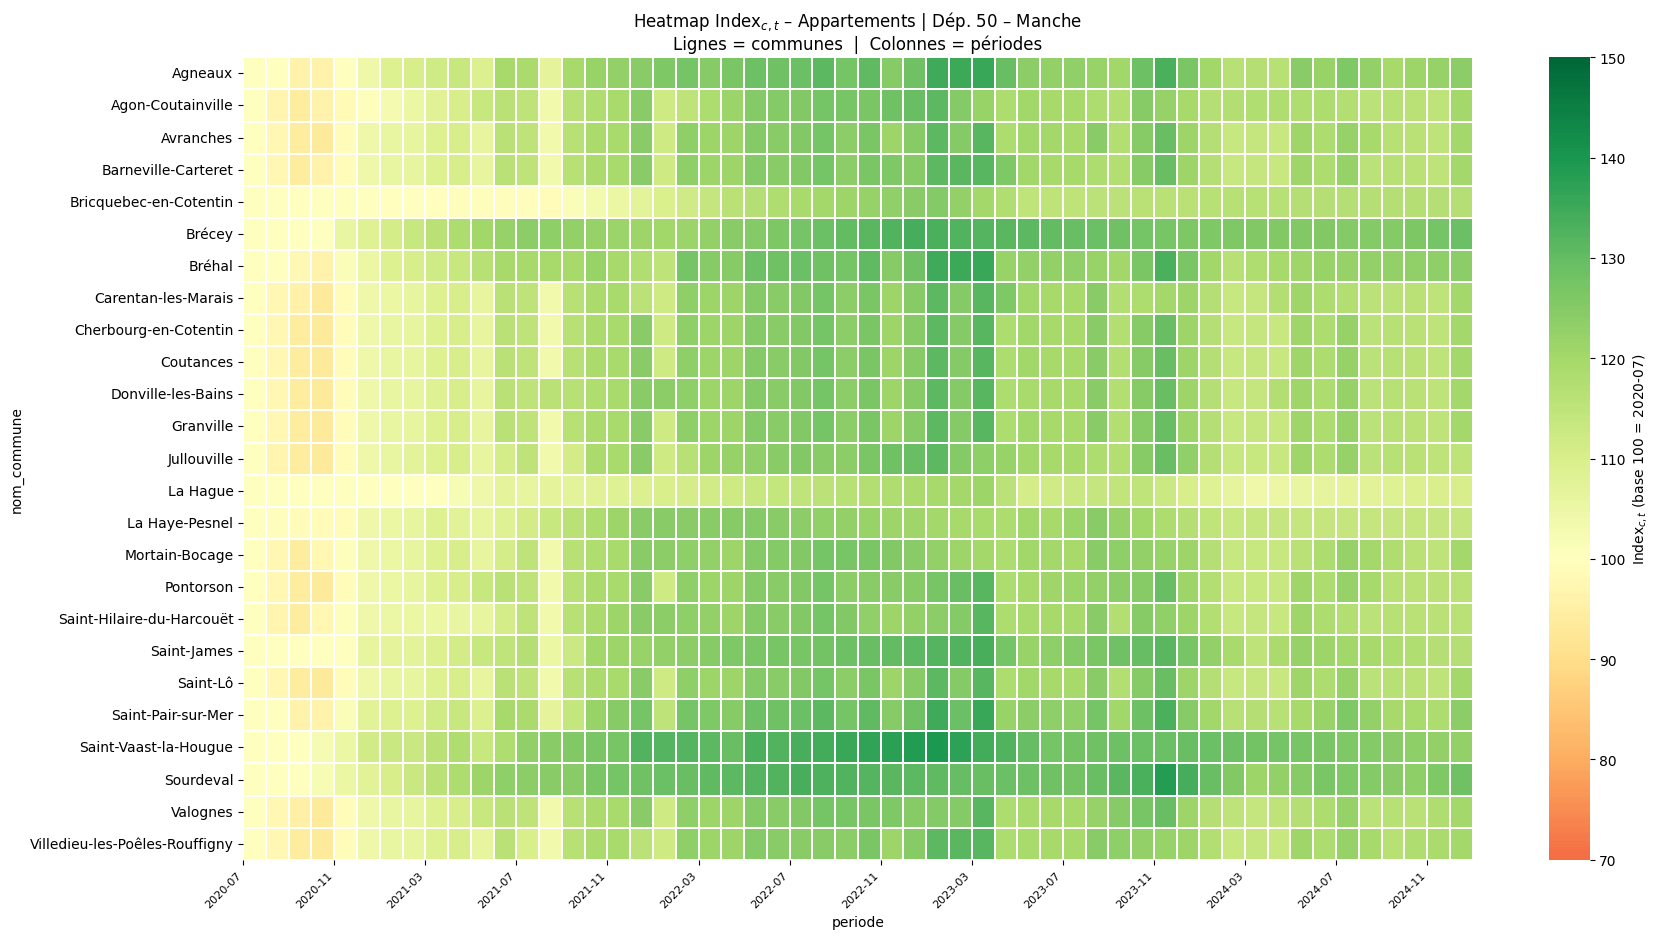

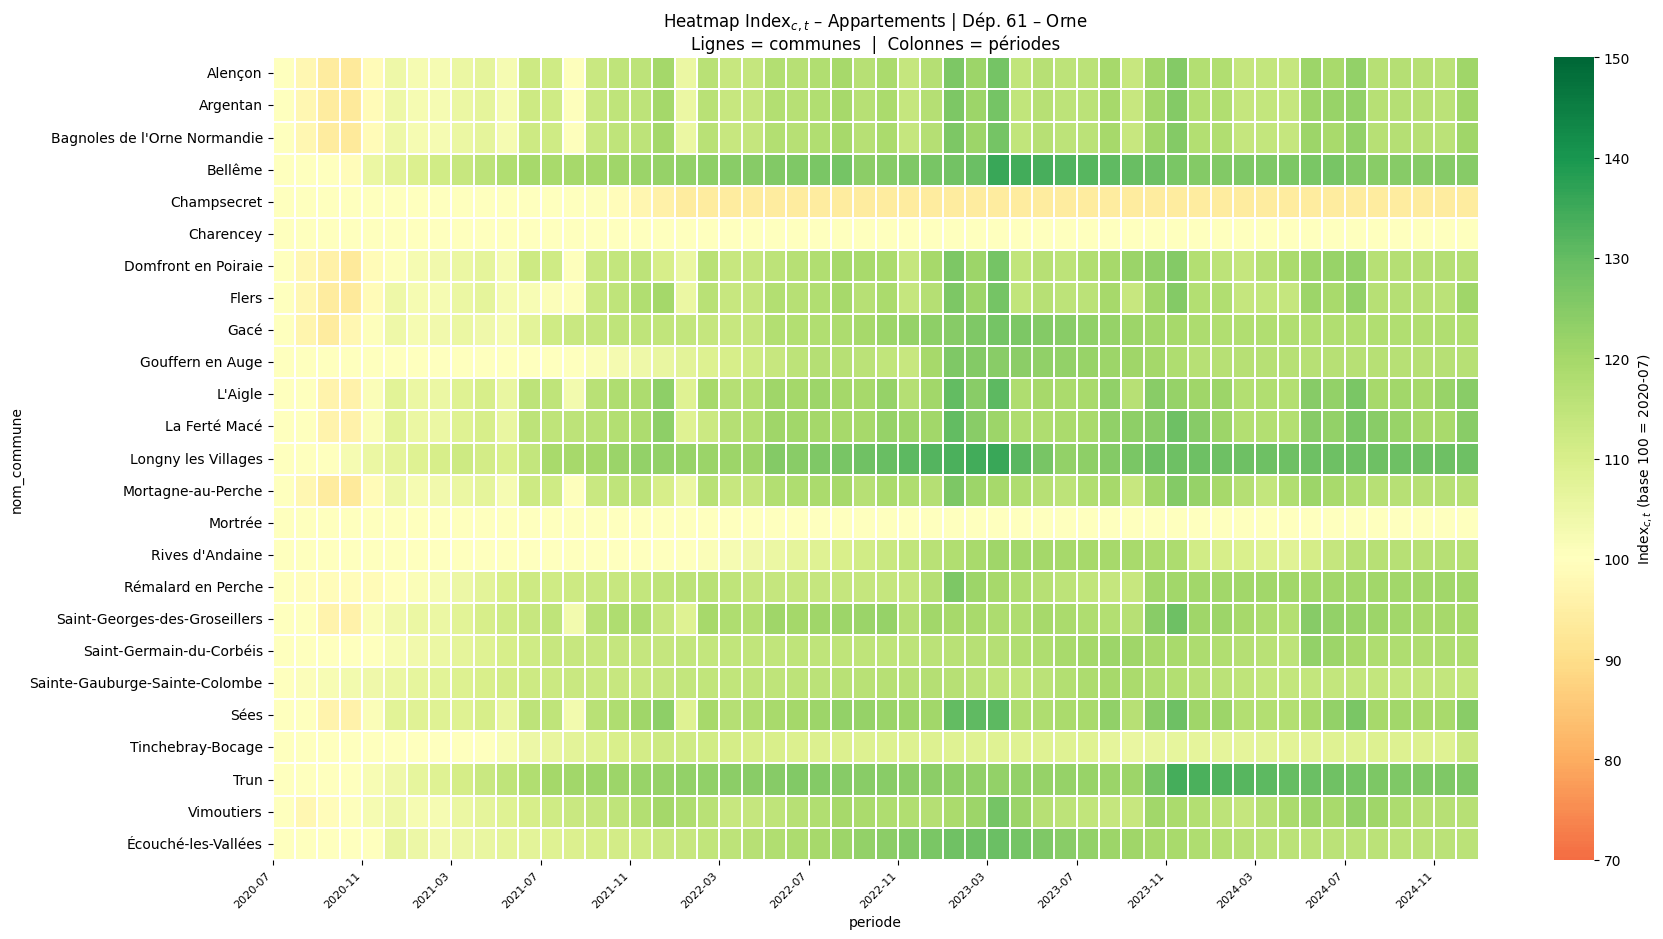

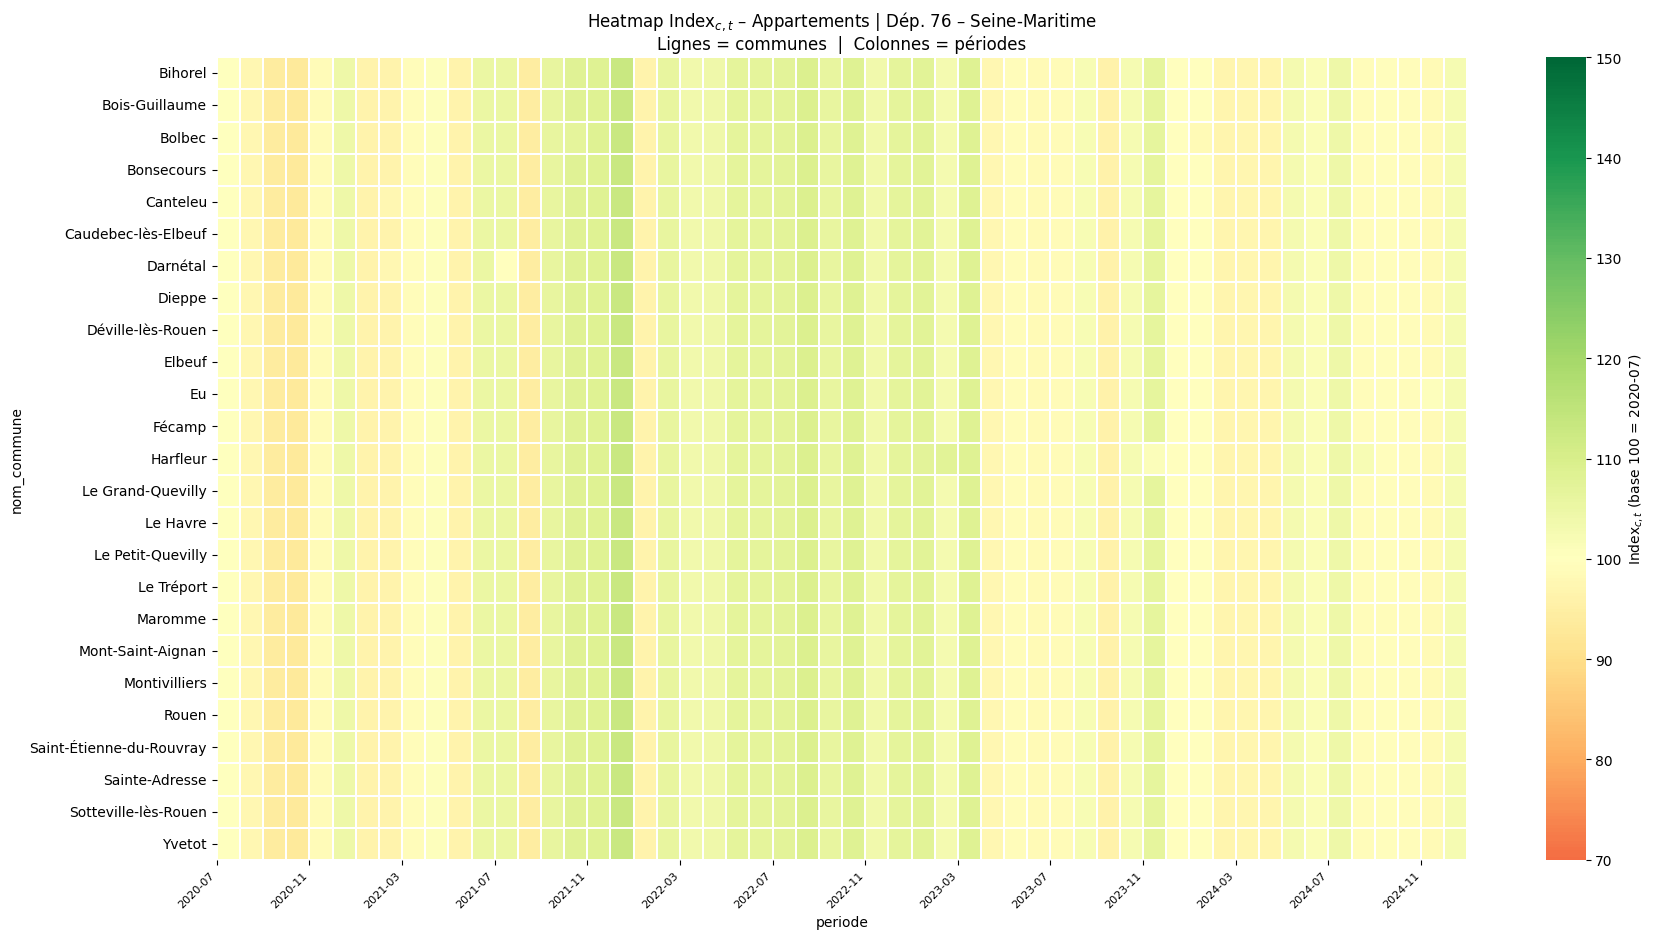


  Tableau récapitulatif – Appartements
Dép.            Nom  Index 2024-12  Croissance (%)  CAGR (% / an)  Communes  Transactions
  14       Calvados          111.2            11.2           2.44       185         27766
  27           Eure          101.7             1.7           0.37       140          8057
  50         Manche          116.3            16.3           3.47       108          7938
  61           Orne          110.1            10.1           2.21       102          4275
  76 Seine-Maritime          102.2             2.2           0.49       210         39985


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# ── 7. Génération des sorties ─────────────────────────────────────────────────
for tb, data in indices.items():
    print(f"\n{'#'*60}\n  Visualisations – {tb}s\n{'#'*60}")
    plot_temporal(data["panel"], data["bench"], tb)
    for dep in DEPARTEMENTS:
        plot_heatmap(data["panel"], tb, dep=dep)
    make_summary_table(data["panel"], data["bench"], tb)

import shutil
shutil.make_archive("resultats_normandie", "zip", "outputs")
try:
    from google.colab import files; files.download("resultats_normandie.zip")
except ImportError:
    print("Archive disponible : resultats_normandie.zip")


############################################################
  Scoring – Maisons
############################################################

════════════════════════════════════════════════════════════════════════════════
  TOP 3 COMMUNES – MAISONS
════════════════════════════════════════════════════════════════════════════════
Rang Dép.  Commune               Index fin   CAGR %      Mom. 12m %    Score   Obs.
────────────────────────────────────────────────────────────────────────────────
  #1  14   Heuland               126.3       5.42++++++++6.05++++++++++0.935   28
  #2  14   Barbeville            123.5       4.90++++++++6.41++++++++++0.919   11
  #3  14   Sallen                126.3       5.42++++++++6.70++++++++++0.915   20
────────────────────────────────────────────────────────────────────────────────
  #1  27   Saint-Benoît-des-Omb  112.2       2.64++++++++6.71++++++++++0.955   26
  #2  27   Saint-Denis-des-Mont  112.2       2.64++++++++6.83++++++++++0.938   29
  #3  27   

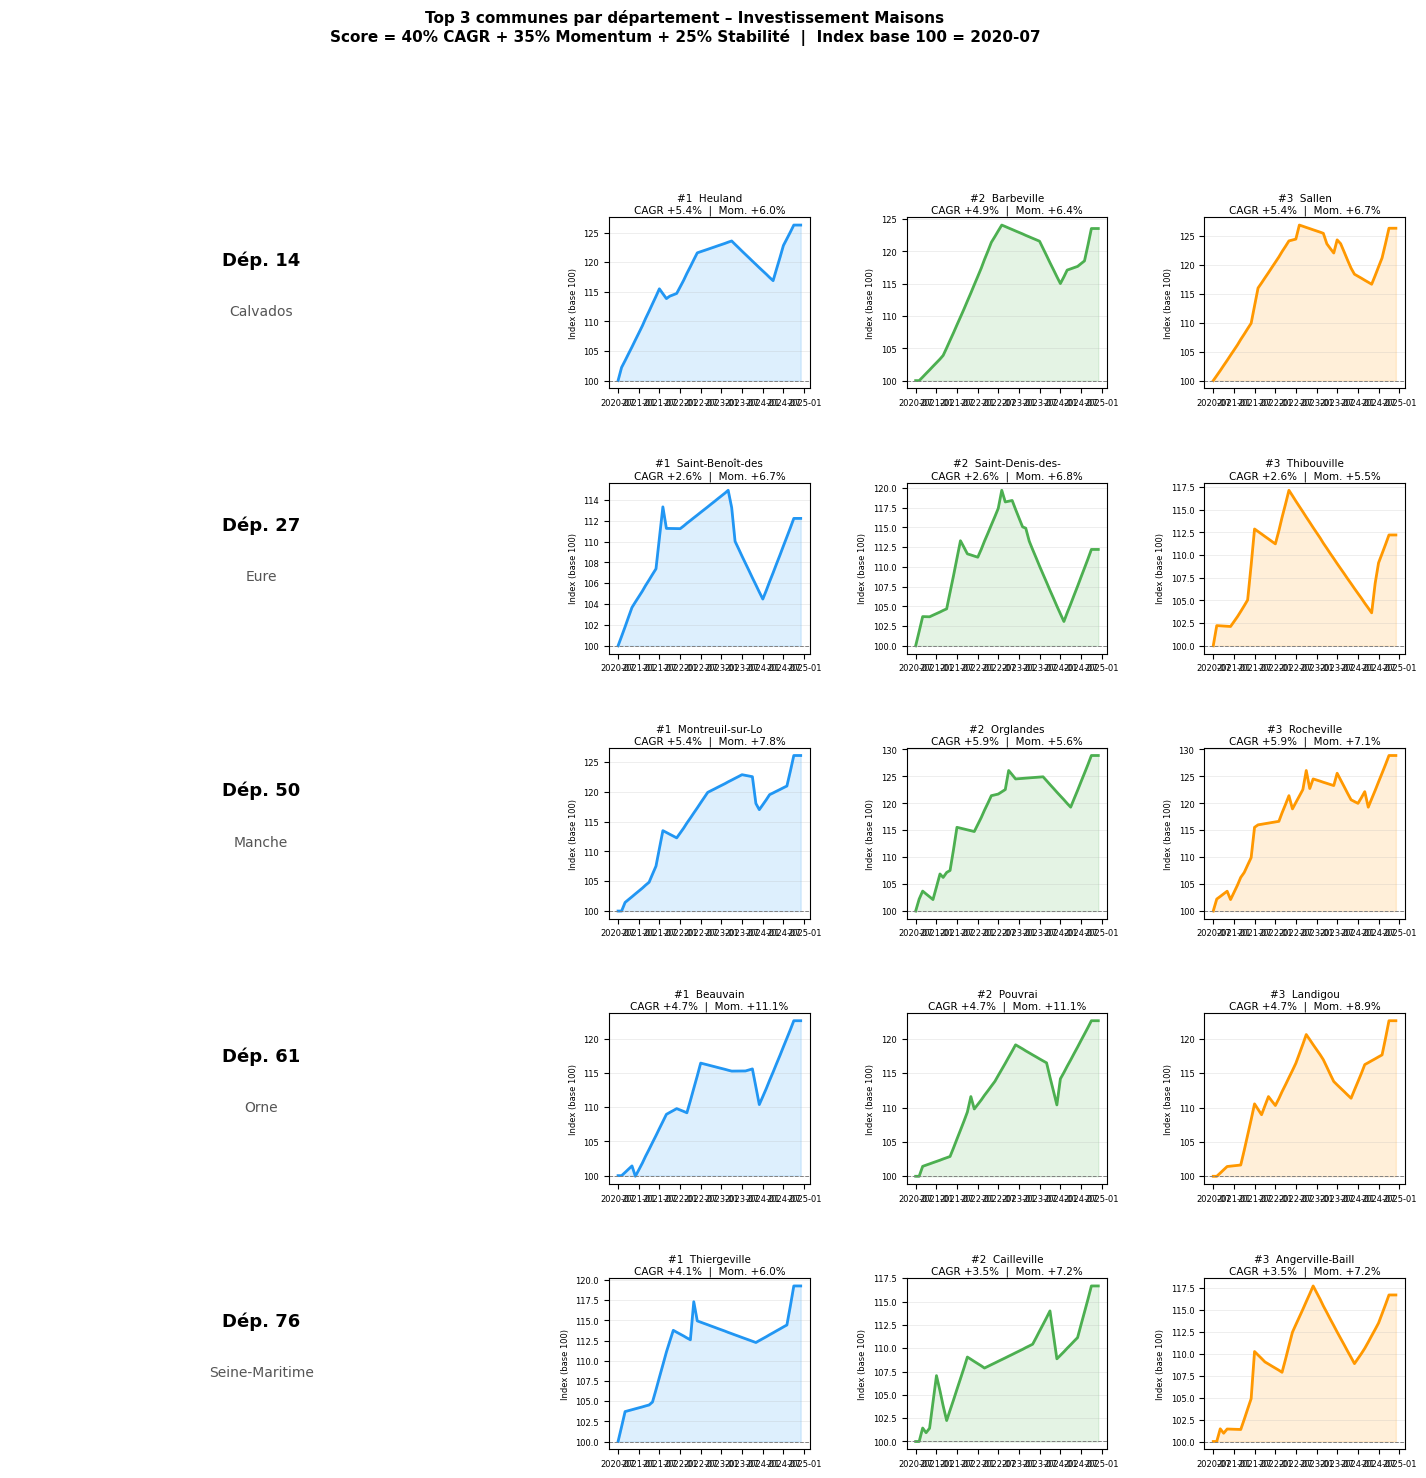

Sauvegardé → outputs/top3_maison.png

############################################################
  Scoring – Appartements
############################################################

════════════════════════════════════════════════════════════════════════════════
  TOP 3 COMMUNES – APPARTEMENTS
════════════════════════════════════════════════════════════════════════════════
Rang Dép.  Commune               Index fin   CAGR %      Mom. 12m %    Score   Obs.
────────────────────────────────────────────────────────────────────────────────
  #1  14   Saint-Rémy            116.4       3.50++++++++5.88++++++++++0.873   16
  #2  14   Bénouville            118.0       3.81++++++++3.19++++++++++0.848   5
  #3  14   Asnelles              118.5       3.91++++++++4.68++++++++++0.817   16
────────────────────────────────────────────────────────────────────────────────
  #1  27   Nassandres sur Risle  110.7       2.33++++++++2.39++++++++++0.864   9
  #2  27   Corneville-sur-Risle  106.4       1.4

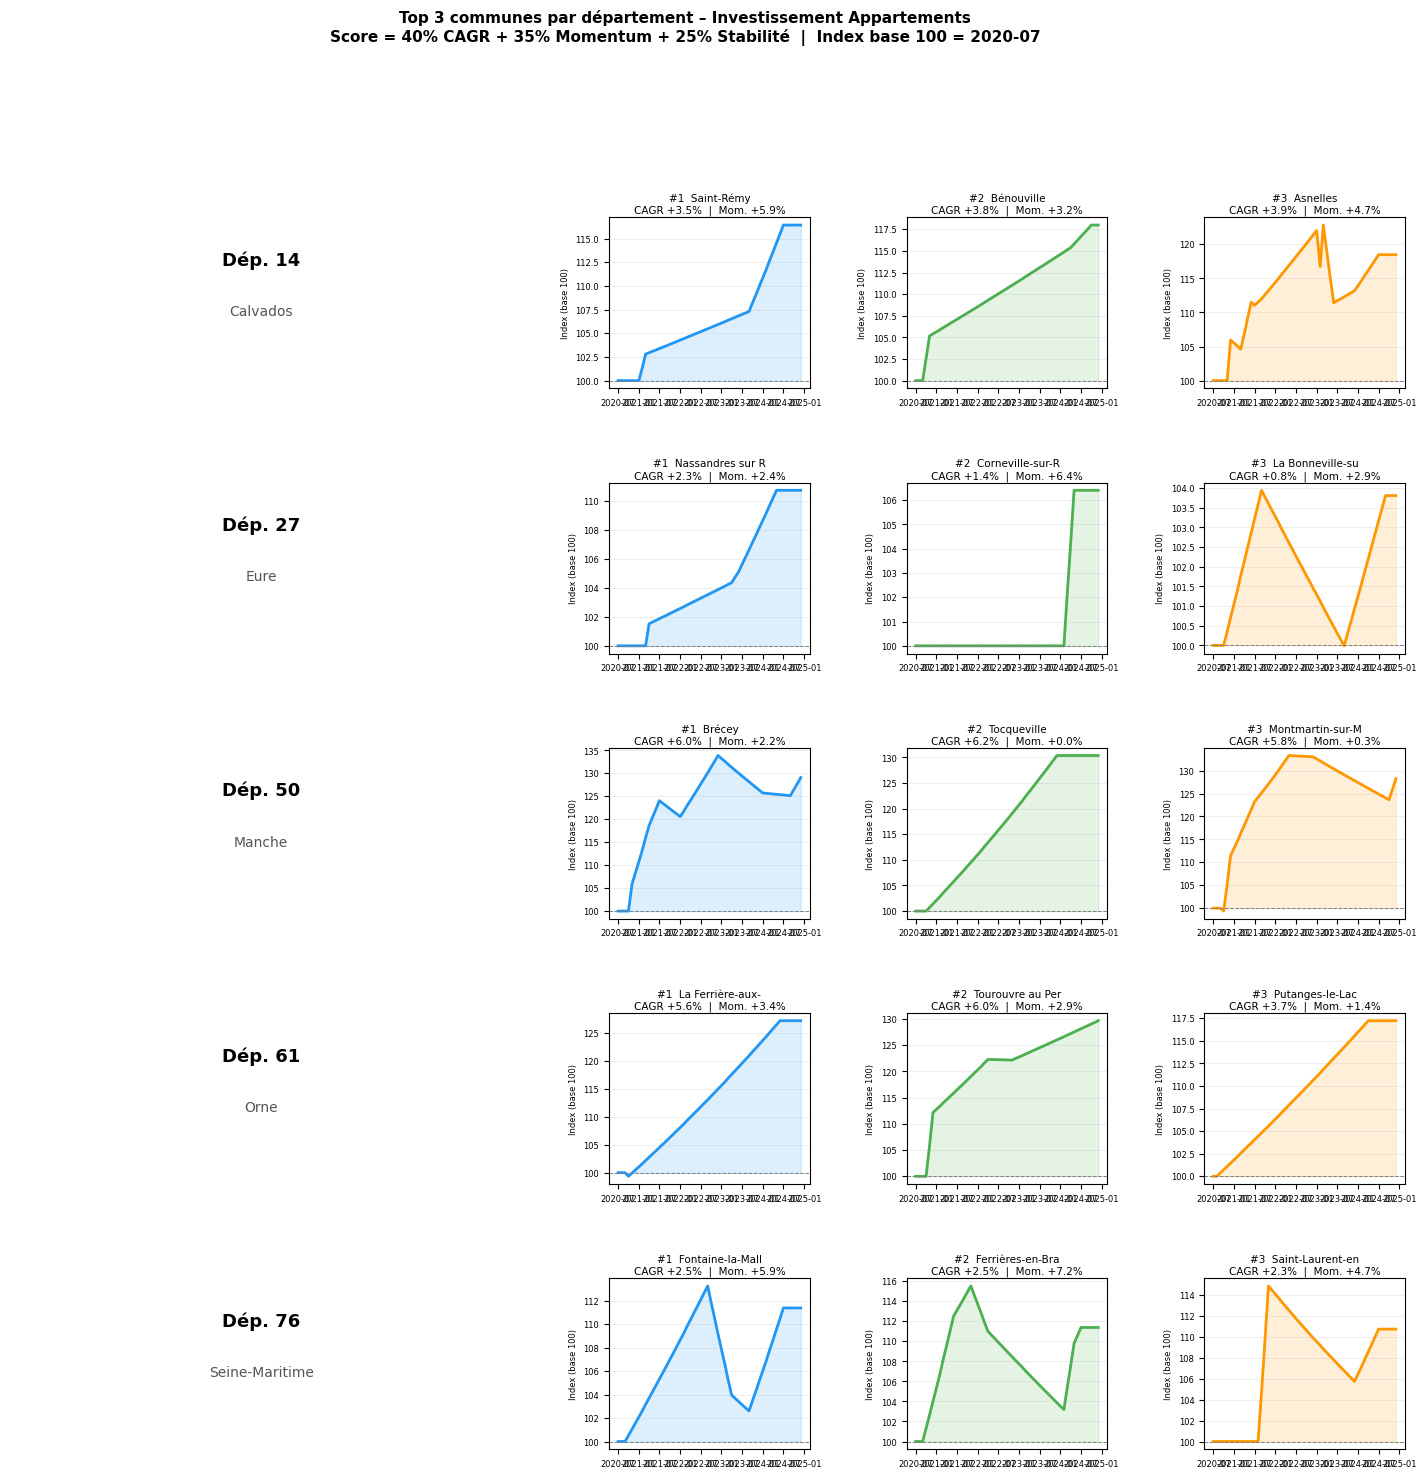

Sauvegardé → outputs/top3_appartement.png

✓ Fichiers sauvegardés dans outputs/


In [9]:
# ── TOP 3 COMMUNES PAR DÉPARTEMENT – ANALYSE D'INVESTISSEMENT ────────────────
# Critères fondés sur l'évolution de Index_{c,t} (cours slides 17-18)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Paramètres ────────────────────────────────────────────────────────────────
DEPARTEMENTS = {"14":"Calvados","27":"Eure","50":"Manche","61":"Orne","76":"Seine-Maritime"}
TOP_N        = 3
# Fenêtre "momentum récent" : 12 derniers mois
MOMENTUM_MOIS = 12

# ── Fonction principale ───────────────────────────────────────────────────────
def score_communes(panel: pd.DataFrame, type_bien: str) -> pd.DataFrame:
    """
    Pour chaque commune, calcule 4 indicateurs issus de Index_{c,t} :

      1. CAGR  – croissance annualisée sur toute la période  [slide 17]
               CAGR = (Index_T / 100)^(1/n_années) − 1

      2. Momentum – variation de l'indice sur les 12 derniers mois
               momentum = (Index_T / Index_{T-12}) − 1

      3. Stabilité – inverse de la volatilité mensuelle de l'indice
               vol = std(Δlog Index_{c,t})
               stabilité = 1 / vol   (plus élevé = plus régulier)

      4. Score composite = 0.4 × CAGR_rank + 0.35 × Momentum_rank + 0.25 × Stabilité_rank
         (rang normalisé [0,1] dans chaque département)
    """
    records = []

    for dep, dep_nom in DEPARTEMENTS.items():
        sub = panel[panel["code_dep"] == dep].copy()
        if sub.empty:
            continue

        periodes = sorted(sub["periode"].unique())
        t_min    = periodes[0]
        t_max    = periodes[-1]
        n_years  = max((pd.to_datetime(t_max) - pd.to_datetime(t_min)).days / 365.25, 0.5)

        # Période T-12 pour le momentum
        idx_t_mom = max(0, len(periodes) - 1 - MOMENTUM_MOIS)
        t_mom     = periodes[idx_t_mom]

        for code_com, grp in sub.groupby("code_commune"):
            grp = grp.sort_values("annee_mois")
            if grp["index_prix"].isna().any() or len(grp) < 6:
                continue

            idx_T   = grp[grp["periode"] == t_max]["index_prix"].values
            idx_mom = grp[grp["periode"] == t_mom]["index_prix"].values

            if len(idx_T) == 0 or len(idx_mom) == 0:
                continue

            idx_T   = idx_T[0]
            idx_mom = idx_mom[0]
            nom_com = grp["nom_commune"].iloc[0]
            n_obs   = int(grp["n_obs"].sum())

            # 1. CAGR  (annualisé)
            cagr = ((idx_T / 100) ** (1 / n_years) - 1) * 100

            # 2. Momentum 12 mois
            momentum = (idx_T / idx_mom - 1) * 100 if idx_mom > 0 else np.nan

            # 3. Stabilité = 1 / vol(Δlog Index)
            log_idx    = np.log(grp["index_prix"].clip(lower=0.01))
            delta_log  = log_idx.diff().dropna()
            vol        = delta_log.std() * 100   # en %
            stabilite  = 1 / vol if vol > 0 else np.nan

            records.append({
                "type_bien"   : type_bien,
                "code_dep"    : dep,
                "dep_nom"     : dep_nom,
                "code_commune": code_com,
                "nom_commune" : nom_com,
                "index_fin"   : round(idx_T, 1),
                "cagr_pct"    : round(cagr,     2),
                "momentum_pct": round(momentum,  2),
                "stabilite"   : round(stabilite, 4),
                "n_obs_total" : n_obs,
            })

    df = pd.DataFrame(records).dropna(subset=["cagr_pct","momentum_pct","stabilite"])

    # ── Score composite par département (rangs normalisés [0,1]) ─────────────
    scored = []
    for dep, grp in df.groupby("code_dep"):
        g = grp.copy()
        for col in ["cagr_pct","momentum_pct","stabilite"]:
            r = g[col].rank(pct=True)
            g[f"rank_{col}"] = r
        g["score"] = (0.40 * g["rank_cagr_pct"]
                    + 0.35 * g["rank_momentum_pct"]
                    + 0.25 * g["rank_stabilite"])
        scored.append(g)

    return pd.concat(scored, ignore_index=True).sort_values(
        ["code_dep","score"], ascending=[True, False]
    )


def top3_par_dep(df_scored: pd.DataFrame) -> pd.DataFrame:
    return (df_scored
            .groupby("code_dep")
            .head(TOP_N)
            .reset_index(drop=True))


# ── Visualisation ─────────────────────────────────────────────────────────────
def plot_top3(panel, df_top3, type_bien):
    deps  = list(DEPARTEMENTS.keys())
    nrows = len(deps)
    fig   = plt.figure(figsize=(18, nrows * 3.2))
    gs    = gridspec.GridSpec(nrows, TOP_N + 1,
                              hspace=0.55, wspace=0.35,
                              width_ratios=[2.5] + [1] * TOP_N)

    cmap = ["#2196F3","#4CAF50","#FF9800"]  # couleur par rang

    for row, dep in enumerate(deps):
        dep_nom = DEPARTEMENTS[dep]
        top     = df_top3[(df_top3["code_dep"] == dep) &
                          (df_top3["type_bien"] == type_bien)]

        # ── Colonne de gauche : titre département ──────────────────────────
        ax_title = fig.add_subplot(gs[row, 0])
        ax_title.axis("off")
        ax_title.text(0.5, 0.75, f"Dép. {dep}", fontsize=13,
                      fontweight="bold", ha="center", va="center",
                      transform=ax_title.transAxes)
        ax_title.text(0.5, 0.45, dep_nom, fontsize=10,
                      ha="center", va="center", color="#555",
                      transform=ax_title.transAxes)

        # ── Colonnes 1-3 : courbe Index_{c,t} de chaque commune ───────────
        for col_idx, (_, row_com) in enumerate(top.iterrows()):
            ax = fig.add_subplot(gs[row, col_idx + 1])
            code_com = row_com["code_commune"]
            serie    = (panel[(panel["code_commune"] == code_com) &
                              (panel["type_local"] == type_bien)]
                        .sort_values("annee_mois"))

            if serie.empty:
                ax.axis("off"); continue

            color = cmap[col_idx]
            ax.plot(serie["annee_mois"], serie["index_prix"],
                    color=color, lw=2)
            ax.fill_between(serie["annee_mois"], 100,
                            serie["index_prix"].clip(lower=100),
                            alpha=0.15, color=color)
            ax.axhline(100, color="grey", lw=0.7, ls="--")

            # Annotations
            nom  = row_com["nom_commune"][:16]
            rank = col_idx + 1
            ax.set_title(
                f"#{rank}  {nom}\n"
                f"CAGR {row_com['cagr_pct']:+.1f}%  |  "
                f"Mom. {row_com['momentum_pct']:+.1f}%",
                fontsize=7.5, pad=3
            )
            ax.tick_params(axis="both", labelsize=6)
            ax.set_ylabel("Index (base 100)", fontsize=6)
            ax.grid(axis="y", alpha=0.3, lw=0.5)

    fig.suptitle(
        f"Top {TOP_N} communes par département – Investissement {type_bien}s\n"
        f"Score = 40% CAGR + 35% Momentum + 25% Stabilité  |  "
        f"Index base 100 = {panel['periode'].min()}",
        fontsize=11, fontweight="bold", y=1.01
    )
    plt.savefig(f"outputs/top3_{type_bien.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Sauvegardé → outputs/top3_{type_bien.lower()}.png")


def print_tableau(df_top3, type_bien):
    print(f"\n{'═'*80}")
    print(f"  TOP {TOP_N} COMMUNES – {type_bien.upper()}S")
    print(f"{'═'*80}")
    print(f"{'Rang':<5}{'Dép.':<6}{'Commune':<22}"
          f"{'Index fin':<12}{'CAGR %':<12}{'Mom. 12m %':<14}"
          f"{'Score':<8}{'Obs.'}")
    print("─" * 80)

    for dep, grp in df_top3[df_top3["type_bien"] == type_bien].groupby("code_dep"):
        for i, (_, r) in enumerate(grp.iterrows()):
            print(f"  #{i+1}  {r['code_dep']:<5}{r['nom_commune'][:20]:<22}"
                  f"{r['index_fin']:<12.1f}{r['cagr_pct']:+<12.2f}"
                  f"{r['momentum_pct']:+<14.2f}{r['score']:<8.3f}"
                  f"{r['n_obs_total']:,}")
        print("─" * 80)


# ── Exécution ─────────────────────────────────────────────────────────────────
# Chargement des indices déjà construits (variables `indices` du script principal)
# Si tu relances ce script seul, remplace par :
#   panel_m = pd.read_csv("outputs/indices/index_commune_maison.csv")
#   panel_m["annee_mois"] = pd.to_datetime(panel_m["annee_mois"])

all_results = {}

for type_bien, data in indices.items():
    panel  = data["panel"].copy()
    panel["type_local"] = type_bien   # nécessaire pour le graphique

    print(f"\n{'#'*60}\n  Scoring – {type_bien}s\n{'#'*60}")
    df_scored = score_communes(panel, type_bien)
    df_top3   = top3_par_dep(df_scored)
    all_results[type_bien] = df_top3

    print_tableau(df_top3, type_bien)
    plot_top3(panel, df_top3, type_bien)

    df_scored.to_csv(f"outputs/scoring_{type_bien.lower()}.csv", index=False)
    df_top3.to_csv(f"outputs/top3_{type_bien.lower()}.csv",  index=False)

print("\n✓ Fichiers sauvegardés dans outputs/")